# XBTorch::Example 09: Hardware-Aware Language Model Evaluation

## Introduction

In this example, we demonstrate how to use **XBTorch** to evaluate large language models (LLMs)
under simulated hardware noise and quantization effects.
This notebook uses the [`lm_eval`](https://github.com/EleutherAI/lm-evaluation-harness)
framework [1] for standardized evaluation, while wrapping the model with XBTorch's inference accelerator.

Contrary to Example 07 on hardware-aware inference, here we will use the stateless mode of operation for the inference accelerator. This is because maintaining a stateful representation of a crossbar that is large enough to fit all parameters of an LLM would be cost-prohibitive.

This enables researchers to **quantify degradation in performance** due to things like ADC/DAC bit precision limits
and analog crossbar variability.

---
**Key Concepts**
- Integrating XBTorch into transformer model evaluation
- Simulating low-precision analog inference with `SimpleFixedPoint`
- Measuring task accuracy using `lm_eval`

**We’ll demonstrate this using a Hugging Face model on the PIQA benchmark.**
---

## Getting Started

Let's begin by importing the required dependencies.

In [1]:
# General imports
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM

# LM Evaluation Harness imports
from lm_eval import evaluator
from lm_eval.models.huggingface import HFLM

# XBTorch imports
import xbtorch
from xbtorch.patches import xbtorch_model
from xbtorch.deployment import SimpleFixedPoint

/mnt/osama.yousuf1/xbtorch/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W1010 23:09:48.035000 2851489 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W1010 23:09:48.035000 2851489 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


In [2]:
def noisy_lm_evaluate(
    model_path,
    eval_tasks,
    acc=None,
    eval_limit=None,
    num_fewshot=0,
    exclude=None,
    batch_size=32,
    **config_kwargs
):
    """
    Evaluate a Hugging Face causal LM under simulated noisy inference conditions
    using XBTorch's SimpleFixedPoint accelerator and lm-evaluation-harness.

    Parameters
    ----------
    model_path : str
        Path or Hugging Face Hub ID of the pretrained model.
    eval_tasks : list[str]
        Evaluation tasks (e.g., ["piqa", "hellaswag"]).
    eval_limit : int, optional
        Number of examples to limit evaluation to.
    num_fewshot : int, optional
        Number of few-shot examples per evaluation (default: 0).
    exclude : list[str], optional
        Layer names to exclude from XBTorch patching (default: ["lm_head"]).
    batch_size : int, optional
        Batch size used during evaluation.
    config_kwargs : dict
        Extra keyword arguments forwarded to model loading.

    Returns
    -------
    dict
        A dictionary containing task results (accuracy, perplexity, etc.)
    """
    if exclude is None:
        exclude = []

    device =  "cuda:0" if torch.cuda.is_available() else "cpu"

    # --- Step 1: Initialize inference accelerator ---
    if (acc is None):
        acc = SimpleFixedPoint(
            g_min=100,
            g_max=200,
            adc_bits=8,
            dac_bits=8,
            device=device,
            stateful=False # This is critical! LLMs can be too big for the stateful mode of operation.
        )

    xbtorch.initialize(
        inference_accelerator=acc,
        pytorch_device=device
    )

    # --- Step 2: Load pretrained model ---
    default_config_kwargs = {
        "device_map": device,
        "trust_remote_code": True,
    }
    config_kwargs = {**default_config_kwargs, **config_kwargs}

    model = AutoModelForCausalLM.from_pretrained(model_path, **config_kwargs)
    model = xbtorch_model(model, replace_all=True, exclude=exclude)
    model.xb_eval(enable=True)

    tokenizer = AutoTokenizer.from_pretrained(model_path)

    # --- Step 3: Prepare evaluation harness ---
    patched_lm_eval_model = HFLM(
        pretrained=model,
        tokenizer=tokenizer,
        batch_size=batch_size
    )

    # --- Step 4: Run evaluation ---
    patched_results = evaluator.simple_evaluate(
        model=patched_lm_eval_model,
        tasks=eval_tasks,
        num_fewshot=num_fewshot,
        limit=eval_limit
    )

    return patched_results["results"]

## Hardware-Aware Evaluation Example

Let’s now apply this function to a transformer model on the **PIQA** task. We will use [SpectraSuite's TriLM models](https://huggingface.co/SpectraSuite) [2] for this purpose.
You can substitute any Hugging Face model and benchmark supported by `lm_eval`.

In [3]:
eval_tasks = ["piqa"]      # Task(s) to evaluate
num_fewshot = 0            # Zero-shot evaluation
eval_limit = 200#None            # Limit evaluation samples for speed
batch_size = 40

models = [
            "SpectraSuite/TriLM_830M_Unpacked", 
            "SpectraSuite/TriLM_3.9B_Unpacked"
         ]

# Optionally, you can define a sweep for ADC/DAC precision bits
layer_sweep_params = {
    "adc_dac_bits": [4, 8, 16]
}

## Performing the Evaluation

We can now loop over models (and optionally over ADC/DAC precision values)
to observe how quantization affects performance.

In [4]:
results_summary = {}

for model_path in models:
    print(f"Evaluating model: {model_path}")
    result = noisy_lm_evaluate(
        model_path=model_path,
        eval_limit=eval_limit,
        batch_size=batch_size,
        num_fewshot=num_fewshot,
        eval_tasks=eval_tasks,
        exclude=["lm_head"]
    )

    results_summary[model_path] = result
    print(result)

Evaluating model: SpectraSuite/TriLM_830M_Unpacked


`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
Overwriting default num_fewshot of piqa from None to 0
Running loglikelihood requests: 100%|█████████████████████████████████████████████████| 400/400 [00:33<00:00, 11.92it/s]


{'piqa': {'alias': 'piqa', 'acc,none': 0.635, 'acc_stderr,none': 0.03412767927155776, 'acc_norm,none': 0.675, 'acc_norm_stderr,none': 0.033202212797844806}}
Evaluating model: SpectraSuite/TriLM_3.9B_Unpacked


Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████| 2/2 [00:10<00:00,  5.37s/it]
`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
Overwriting default num_fewshot of piqa from None to 0
Running loglikelihood requests: 100%|█████████████████████████████████████████████████| 400/400 [00:45<00:00,  8.71it/s]


{'piqa': {'alias': 'piqa', 'acc,none': 0.67, 'acc_stderr,none': 0.03333249580187342, 'acc_norm,none': 0.695, 'acc_norm_stderr,none': 0.03263741725420572}}


## (Optional) Parameter Sweep

To simulate progressively more aggressive quantization,
we can vary the ADC/DAC bit precision of the inference accelerator.

Note: this section can be time-consuming for large models.

In [5]:
sweep_results = {}

for bits in layer_sweep_params["adc_dac_bits"]:
    print(f"Testing with ADC/DAC precision = {bits} bits")

    acc = SimpleFixedPoint(
        g_min=100,
        g_max=200,
        adc_bits=bits,
        dac_bits=bits,
        device="cuda" if torch.cuda.is_available() else "cpu",
        stateful=False
    )

    xbtorch.initialize(inference_accelerator=acc)

    result = noisy_lm_evaluate(
        model_path=models[0], # using the 830M model for this experiment
        acc=acc,
        eval_limit=eval_limit,
        batch_size=batch_size,
        num_fewshot=num_fewshot,
        eval_tasks=eval_tasks,
        exclude=["lm_head"]
    )

    sweep_results[bits] = result

Testing with ADC/DAC precision = 4 bits


`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
Overwriting default num_fewshot of piqa from None to 0
Running loglikelihood requests: 100%|█████████████████████████████████████████████████| 400/400 [00:07<00:00, 51.70it/s]


Testing with ADC/DAC precision = 8 bits


`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
Overwriting default num_fewshot of piqa from None to 0
Running loglikelihood requests: 100%|█████████████████████████████████████████████████| 400/400 [00:06<00:00, 62.97it/s]


Testing with ADC/DAC precision = 16 bits


`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
Overwriting default num_fewshot of piqa from None to 0
Running loglikelihood requests: 100%|█████████████████████████████████████████████████| 400/400 [00:11<00:00, 34.24it/s]


## Visualization

Let's visualize the effect of ADC/DAC bit precision on task accuracy.

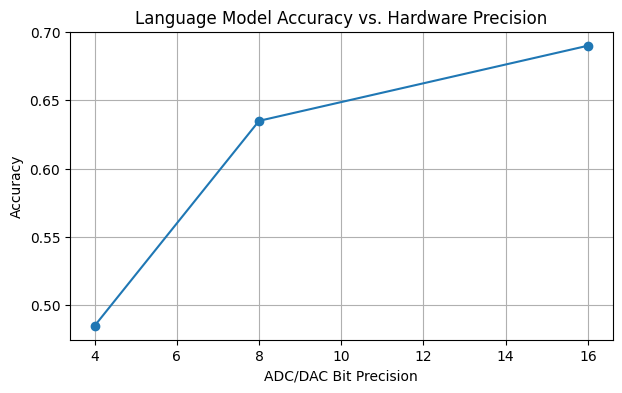

In [6]:
import matplotlib.pyplot as plt

bit_values = list(sweep_results.keys())
accuracies = [
    list(sweep_results[b].values())[0]["acc,none"] for b in bit_values
]

plt.figure(figsize=(7, 4))
plt.plot(bit_values, accuracies, marker='o')
plt.xlabel("ADC/DAC Bit Precision")
plt.ylabel("Accuracy")
plt.title("Language Model Accuracy vs. Hardware Precision")
plt.grid(True)
plt.show()

## Conclusion

We demonstrated how XBTorch can be integrated into the LM Evaluation Harness
to simulate low-precision inference in large language models.

**Key Takeaways:**
- The `SimpleFixedPoint` accelerator enables simulation of analog crossbars and quantization. For large models, the stateful mode of operation can be used.
- Language model evaluation can be done seamlessly using `lm_eval`.
- Reducing ADC/DAC precision degrades model performance, providing a direct measure of hardware sensitivity.

---
**References**
1. Gao et al., *"The Language Model Evaluation Harness*, EleutherAI, 2021.  
2. Kaushal et al., *"Spectra: Surprising effectiveness of pretraining ternary language models at scale"*, 2024.